In [ ]:
!python --version

Python 3.12.13


In [ ]:
import os
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
from scipy.optimize import differential_evolution, minimize

warnings.filterwarnings("ignore")
np.random.seed(42)

## Input param

In [ ]:
S0 = 232.90
RISK_FREE_RATE = 0.015
TRADING_DAYS = 250
OPTION_FILE = "/content/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx"
OUTPUT_DIR = "/content/output_dir"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
# Fixed Gauss-Legendre quadrature grids for fast pricing.
LEWIS_NODES, LEWIS_LIMIT = 64, 100.0
x_l, w_l = np.polynomial.legendre.leggauss(LEWIS_NODES)
U_LEWIS = 0.5 * LEWIS_LIMIT * (x_l + 1.0)
W_LEWIS = 0.5 * LEWIS_LIMIT * w_l

CM_NODES, CM_LIMIT = 80, 120.0
x_cm, w_cm = np.polynomial.legendre.leggauss(CM_NODES)
U_CM = 0.5 * CM_LIMIT * (x_cm + 1.0)
W_CM = 0.5 * CM_LIMIT * w_cm

In [ ]:
# load option_data
option_data = pd.read_excel(OPTION_FILE)
option_data.columns = [str(col).strip().lower().replace(" ", "_") for col in option_data.columns]
display(option_data.head())

,days_to_maturity,strike,price,type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C


In [ ]:
option_data = option_data.rename(columns={"days_to_maturity": "days","type":"option_type"})
option_data["option_type"] = option_data["option_type"].astype(str).str.upper().str.strip()
option_data["T"] = option_data["days"] / TRADING_DAYS
display(option_data.head())

,days,strike,price,option_type,T
0,15,227.5,10.52,C,0.06
1,15,230.0,10.05,C,0.06
2,15,232.5,7.75,C,0.06
3,15,235.0,6.01,C,0.06
4,15,237.5,4.75,C,0.06


In [ ]:
# helper function
def get_maturity_slice(df,days):
  sub = df[df["days"] == days]
  strikes = np.array(sorted(sub["strike"].unique()),dtype=float)
  calls = np.array([sub[(sub["strike"]==k)& (sub["option_type"]=="C")]["price"].iloc[0] for k in strikes])
  puts = np.array([sub[(sub["strike"]==k)& (sub["option_type"]=="P")]["price"].iloc[0] for k in strikes])
  return strikes, calls, puts, days/TRADING_DAYS

In [ ]:
def parity_diagnostic(strikes, calls, puts, T):
  rhs = S0-strikes*np.exp(-RISK_FREE_RATE*T)
  dev = calls-puts-rhs
  lb_mse = np.sum(0.5*dev**2)/(2*len(strikes))
  return pd.DataFrame({
      "strike":strikes,
      "call_minus_put":calls-puts,
      "S0_minus_discounted_K":rhs,
      "parity_deviation":dev,}),lb_mse

def calls_to_puts_by_parity(calls,strikes,T):
  return np.maximum(calls-S0+strikes*np.exp(-RISK_FREE_RATE*T),0.0)

def make_fit_table(strikes,mc,mp,model_calls,T):
  model_puts = calls_to_puts_by_parity(model_calls,strikes,T)
  return pd.DataFrame({
      "Strike":strikes,
      "Market Call":mc,"Model Call":model_calls,"Call Error":model_calls-mc,
      "Market Put":mp,"Model Put":model_puts,"Put Error":model_puts-mp,
  })

def plot_fit(table,title,filename):
  plt.figure(figsize=(9,6))
  plt.scatter(table["Strike"],table["Market Call"],label="Market calls",marker="o")
  plt.plot(table["Strike"],table["Model Call"],label="Model Call",marker="x",linestyle="--")
  plt.scatter(table["Strike"],table["Market Put"],label="Market puts",marker="o")
  plt.plot(table["Strike"],table["Model Put"],label="Model Put",marker="x",linestyle="--")
  plt.xlabel("Strike");plt.ylabel("Option Price");plt.title(title)
  plt.legend();plt.grid(alpha=0.3);plt.tight_layout()
  path = os.path.join(OUTPUT_DIR,filename)
  plt.savefig(path,dpi=300);plt.show()
  return path


def plot_errors(table,title,filename):
  plt.figure(figsize=(9,6))
  plt.axhline(0,linestyle="--",linewidth=1)
  plt.scatter(table["Strike"],table["Call Error"],label="Call Error")
  plt.scatter(table["Strike"],table["Put Error"],label="Put Error")
  plt.xlabel("Strike");plt.ylabel("Error");plt.title(title)
  plt.legend();plt.grid(alpha=0.3);plt.tight_layout()
  path = os.path.join(OUTPUT_DIR,filename)
  plt.savefig(path,dpi=300);plt.show()
  return path
#
def plot_errors(table,title,filename):
  plt.figure(figsize=(9,6))
  plt.axhline(0,linestyle="--",linewidth=1)
  plt.scatter(table["Strike"],table["Call Error"],label="Call Error")
  plt.scatter(table["Strike"],table["Put Error"],label="Put Error")
  plt.xlabel("Strike");plt.ylabel("Error");plt.title(title)
  plt.legend();plt.grid(alpha=0.3);plt.tight_layout()
  path = os.path.join(OUTPUT_DIR,filename)
  plt.savefig(path,dpi=300);plt.show()
  return path

def params_to_dataframe(params,mse,model_name,fields):
  rows = [(f,getattr(params,f)) for f in fields]+[("MSE",mse),("RMSE",np.sqrt(mse))]
  out = pd.DataFrame(rows,columns=["parameter","value"])
  out.insert(0,"model",model_name)
  return out


In [ ]:
# Heston Lewis pricing model

In [ ]:
@dataclass
class HestonParams:
  kappa:float
  theta:float
  sigma_v:float
  rho: float
  v0:float


def heston_return_cf(u,T,r,p):
  u = np.asarray(u,dtype=complex)
  c1=p.kappa*p.theta

  c2 = np.sqrt((p.rho*p.sigma_v*u*1j-p.kappa)**2 - p.sigma_v**2*(-u*1j-u**2))
  c2 = np.where(np.real(c2) < 0, -c2, c2)
  c2 = -c2
  c3= (p.kappa-p.rho*p.sigma_v*u*1j+c2)/(p.kappa-p.rho*p.sigma_v*u*1j-c2)
  e = np.exp(c2*T)

  eps = 1e-12

  H1 = (r*u*1j*T+(c1/p.sigma_v**2)*((p.kappa-p.rho*p.sigma_v*u*1j+c2)*T-2.0*np.log((1.0-c3*e+eps)/(1.0-c3+eps))))
  H2= ((p.kappa-p.rho*p.sigma_v*u*1j+c2)/p.sigma_v**2)*((1.0-e)/(1.0-c3*e+eps))

  return np.exp(H1+H2*p.v0)


def heston_lewis_call_prices(strikes,T,p):
  u=U_LEWIS
  cf=heston_return_cf(u-0.5j,T,RISK_FREE_RATE,p)

  expo = np.exp(1j*u[:,None]*np.log(S0/strikes[None,:]))

  integrand = np.real(expo*cf[:,None])/(u[:,None]**2+0.25)
  integral = W_LEWIS@integrand

  calls = S0-(np.sqrt(S0*strikes)*np.exp(-RISK_FREE_RATE*T)/np.pi)*integral
  return np.maximum(calls,0.0)


def heston_residuals(x,K,MC,MP,T):
  p = HestonParams(*x)

  if 2*p.kappa*p.theta <= p.sigma_v**2:
    return np.ones(2*len(K))*1e5

  try:
    c = heston_lewis_call_prices(K,T,p)
    pu = calls_to_puts_by_parity(c,K,T)
    r = np.r_[c-MC,pu-MP]
    return r if np.all(np.isfinite(r)) else np.ones(2*len(K))*1e5
  except Exception:
    return np.ones(2*len(K))*1e5


def heston_mse(x,K,MC,MP,T):
  return float(np.mean(heston_residuals(x,K,MC,MP,T)**2))


def calibrate_heston_lewis(K,MC,MP,T):
  bounds = [(0.01,20.0),(1e-6,2.0),(0.01,5.0),(-0.999,0.999),(1e-6,2.0)]
  obj = lambda x: heston_mse(x,K,MC,MP,T)

  g = differential_evolution(obj,bounds,seed=777,maxiter=80,popsize=12,tol=1e-8,polish=False,updating="immediate",workers=1)
  l = minimize(obj,g.x,method="L-BFGS-B",bounds=bounds,options={"maxiter":1000,"ftol":1e-14})

  return HestonParams(*l.x),obj(l.x)

## Step 1(a): slice 15 day options & parity check

In [ ]:
K15,C15,P15,T15=get_maturity_slice(option_data,15)
parity15,party15_lb=parity_diagnostic(K15,C15,P15,T15)
display(Markdown(f"**15-day slice** {len(K15)} strikes,T= {T15:.5f} years"))

display(parity15)

display(Markdown(f"Parity-constrained lower bounds MSE: **{party15_lb:0.6f}**"))


**15-day slice** 5 strikes,T= 0.06000 years

,strike,call_minus_put,S0_minus_discounted_K,parity_deviation
0,227.5,6.20,5.604658,0.595342
1,230.0,4.85,3.106907,1.743093
2,232.5,1.30,0.609156,0.690844
3,235.0,-1.55,-1.888595,0.338595
4,237.5,-4.03,-4.386346,0.356346


Parity-constrained lower bounds MSE: **0.205585**

## Step 1(a)- Calibrate Heston-Lewis & report parameters

In [ ]:
heston_params,heston_mse_val = calibrate_heston_lewis(K15,C15,P15,T15)
heston_param_table = params_to_dataframe(heston_params,heston_mse_val,"Heston-Lewis",["kappa","theta","sigma_v","rho","v0"])

heston_param_table.to_csv(os.path.join(OUTPUT_DIR,"step1a_heston__lewis_params.csv"),index=False)
parity15.to_csv(os.path.join(OUTPUT_DIR,"step1a_parity_diagnostic.csv"),index=False)
display(Markdown(f"**Heston-Lewis parameters**"))
display(heston_param_table)

**Heston-Lewis parameters**

,model,parameter,value
0,Heston-Lewis,kappa,3.022470
1,Heston-Lewis,theta,0.319670
2,Heston-Lewis,sigma_v,1.316672
3,Heston-Lewis,rho,-0.999000
4,Heston-Lewis,v0,0.081105
5,Heston-Lewis,MSE,0.246449
6,Heston-Lewis,RMSE,0.496436


## Step 1(a) - fit table and plots

**Heston-Lewis fit table**

,Strike,Market Call,Model Call,Call Error,Market Put,Model Put,Put Error
0,227.5,10.52,10.505066,-0.014934,4.32,4.900408,0.580408
1,230.0,10.05,8.852315,-1.197685,5.20,5.745408,0.545408
2,232.5,7.75,7.316563,-0.433437,6.45,6.707407,0.257407
3,235.0,6.01,5.910971,-0.099029,7.56,7.799566,0.239566
4,237.5,4.75,4.644812,-0.105188,8.78,9.031158,0.251158


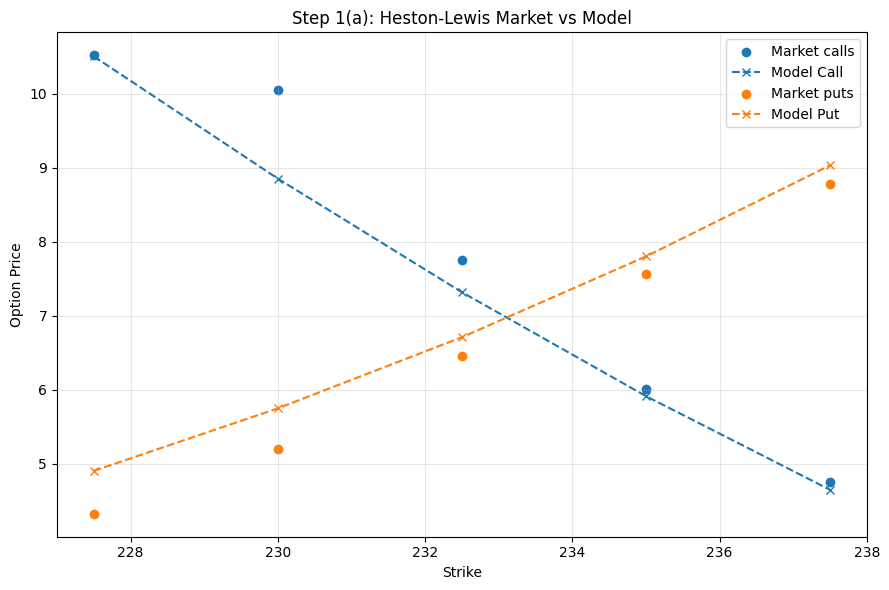

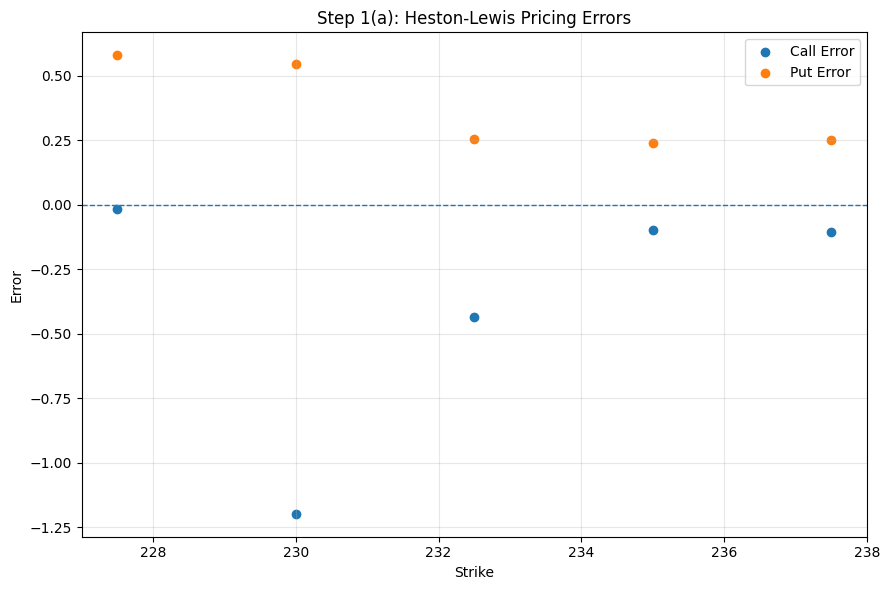

'/content/output_dir/step1a_heston_lewis_errors.png'

In [ ]:
heston_model_calls = heston_lewis_call_prices(K15,T15,heston_params)
heston_fit = make_fit_table(K15,C15,P15,heston_model_calls,T15)
heston_fit.to_csv(os.path.join(OUTPUT_DIR,"step1a_fit_table.csv"),index=False)

display(Markdown(f"**Heston-Lewis fit table**"))
display(heston_fit)

plot_fit(heston_fit,"Step 1(a): Heston-Lewis Market vs Model","step1a_heston_lewis_fit.png")
plot_errors(heston_fit,"Step 1(a): Heston-Lewis Pricing Errors","step1a_heston_lewis_errors.png")


## Bates-Carr-Madan Pricing Model

In [ ]:
@dataclass
class BatesParams:
    kappa: float
    theta: float
    sigma_v: float
    rho: float
    v0: float
    lambda_j: float
    mu_j: float
    delta_j: float


def heston_log_stock_cf(u, T, r, p: HestonParams):
    return np.exp(1j * u * np.log(S0)) * heston_return_cf(u, T, r, p)


def bates_log_stock_cf(u, T, r, p: BatesParams):
    hp = HestonParams(p.kappa, p.theta, p.sigma_v, p.rho, p.v0)
    comp = np.exp(p.mu_j + 0.5 * p.delta_j**2) - 1.0
    heston_part = heston_log_stock_cf(u, T, r - p.lambda_j * comp, hp)
    jump_part = np.exp(p.lambda_j * T * (np.exp(1j * u * p.mu_j - 0.5 * p.delta_j**2 * u**2) - 1.0))

    return heston_part * jump_part


def carr_madan_call_prices(strikes, T, cf_func, alpha=1.5):
    u = U_CM
    k = np.log(strikes)
    # cf = cf_func(u - 1j * (alpha + 1.0))
    cf = np.asarray(cf_func(u - 1j * (alpha + 1.0))).reshape(-1)
    denom = alpha**2 + alpha - u**2 + 1j * (2.0 * alpha + 1.0) * u
    integrand = np.real(
        np.exp(-1j * u[:, None] * k[None, :]) *
        (np.exp(-RISK_FREE_RATE * T) * (cf / denom)[:, None])

    )


    integral = W_CM @ integrand
    return np.maximum(np.exp(-alpha * k) * integral / np.pi, 0.0)


def bates_carr_madan_call_prices(strikes, T, p: BatesParams):
    return carr_madan_call_prices(
        strikes,
        T,
        lambda u: bates_log_stock_cf(u, T, RISK_FREE_RATE, p),
        alpha=1.5
    )


def bates_residuals(x, K, MC, MP, T):
    p = BatesParams(*x)

    try:
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            c = bates_carr_madan_call_prices(K, T, p)
            pu = calls_to_puts_by_parity(c, K, T)
            r = np.r_[c - MC, pu - MP]

        return r if np.all(np.isfinite(r)) else np.ones(2 * len(K)) * 1e5

    except Exception:
        return np.ones(2 * len(K)) * 1e5


def bates_mse(x, K, MC, MP, T):
    return float(np.mean(bates_residuals(x, K, MC, MP, T)**2))


def calibrate_bates_carr_madan(K, MC, MP, T):
    bounds = [
        (0.01, 20.0),
        (1e-6, 2.0),
        (0.01, 5.0),
        (-0.999, 0.999),
        (1e-6, 2.0),
        (0.0, 5.0),
        (-0.5, 0.5),
        (1e-6, 1.5)
    ]

    obj = lambda x: bates_mse(x, K, MC, MP, T)

    g = differential_evolution(
        obj,
        bounds,
        seed=888,
        maxiter=120,
        popsize=12,
        tol=1e-8,
        polish=False,
        updating="immediate",
        workers=1
    )

    l = minimize(
        obj,
        g.x,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 2000, "ftol": 1e-14, "gtol": 1e-8}
    )

    return BatesParams(*l.x), obj(l.x)

## Step 2(b) - slice 60 day options & paraity check

In [ ]:
K60,C60,P60,T60 =get_maturity_slice(option_data,60)
parity60,party60_lb=parity_diagnostic(K60,C60,P60,T60)

display(Markdown(f"**60-day slice:** {len(K60)} strikes,T= {T60:.5f} years"))
display(parity60)

display(Markdown(f"Parity-constrained lower bounds MSE: **{party60_lb:0.6f}**"))


**60-day slice:** 5 strikes,T= 0.24000 years

,strike,call_minus_put,S0_minus_discounted_K,parity_deviation
0,227.5,5.75,6.217528,-0.467528
1,230.0,5.50,3.726511,1.773489
2,232.5,3.49,1.235495,2.254505
3,235.0,1.30,-1.255521,2.555521
4,237.5,-0.52,-3.746537,3.226537


Parity-constrained lower bounds MSE: **1.269393**

## Step 2(b) - calibrate Bates-Carr-Madan & report parameters

In [ ]:
bates_params,bates_mse_val = calibrate_bates_carr_madan(K60,C60,P60,T60)
bates_param_table = params_to_dataframe(bates_params,bates_mse_val,"Bates-Carr-Madan",["kappa","theta","sigma_v","rho","v0","lambda_j","mu_j","delta_j"])

bates_param_table.to_csv(os.path.join(OUTPUT_DIR,"step2b_bates_carr_madan_params.csv"),index=False)
parity60.to_csv(os.path.join(OUTPUT_DIR,"step2_parity_diagnostics.csv"),index=False)
display(Markdown(f"**Bates-Carr-Madan parameters**"))
display(bates_param_table)

**Bates-Carr-Madan parameters**

,model,parameter,value
0,Bates-Carr-Madan,kappa,0.010000
1,Bates-Carr-Madan,theta,0.000001
2,Bates-Carr-Madan,sigma_v,4.382365
3,Bates-Carr-Madan,rho,-0.999000
4,Bates-Carr-Madan,v0,0.026626
5,Bates-Carr-Madan,lambda_j,1.901816
6,Bates-Carr-Madan,mu_j,0.207446
7,Bates-Carr-Madan,delta_j,0.026248
8,Bates-Carr-Madan,MSE,1.326750
9,Bates-Carr-Madan,RMSE,1.151847


## Step 2(b) - fit table and plots

**Bates-Carr-Madan fit table (60-day)**

,Strike,Market Call,Model Call,Call Error,Market Put,Model Put,Put Error
0,227.5,16.78,17.334004,0.554004,11.03,11.116476,0.086476
1,230.0,17.65,16.468066,-1.181934,12.15,12.741554,0.591554
2,232.5,16.86,15.579209,-1.280791,13.37,14.343714,0.973714
3,235.0,16.05,14.654879,-1.395121,14.75,15.910400,1.160400
4,237.5,15.10,13.731165,-1.368835,15.62,17.477702,1.857702


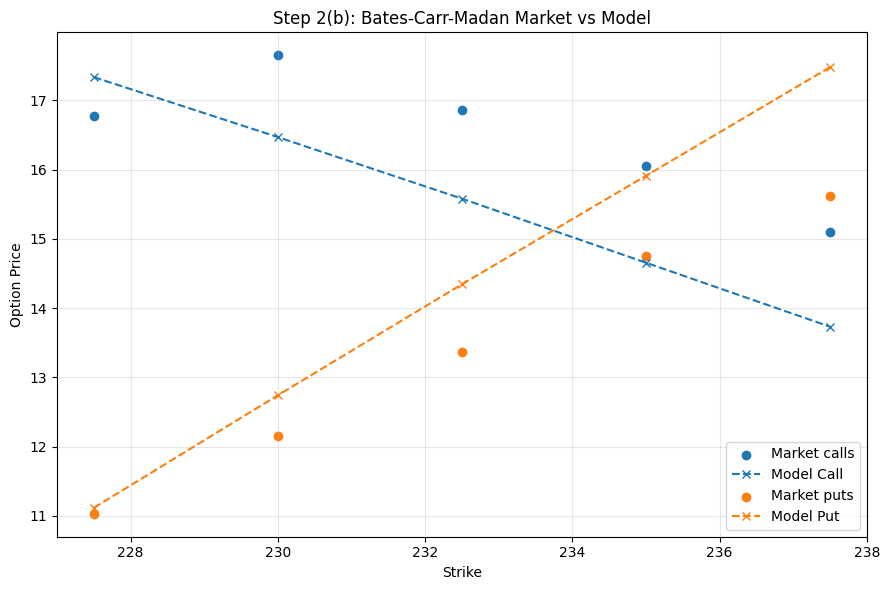

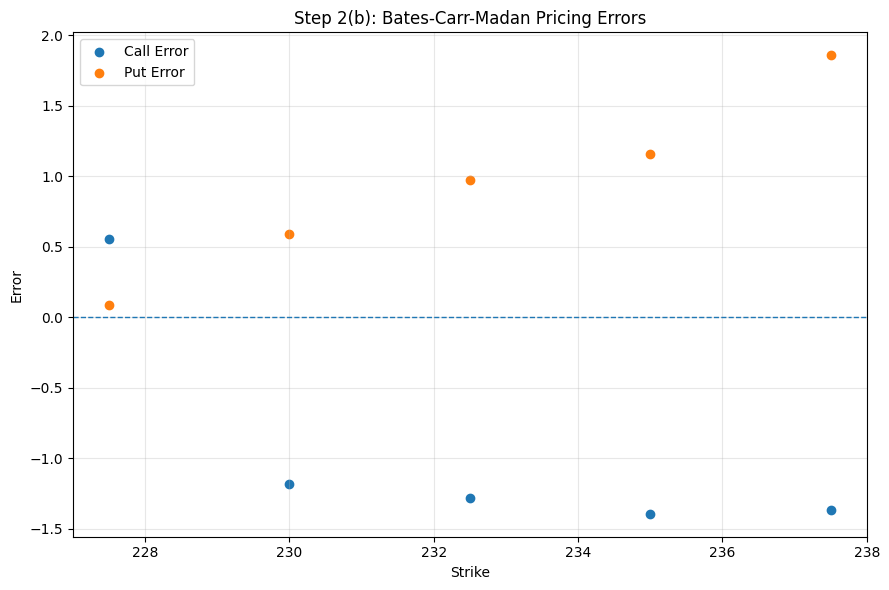

'/content/output_dir/step2b_bates_carr_madan_errors.png'

In [ ]:
bates_model_calls= bates_carr_madan_call_prices(K60,T60,bates_params)
bates_fit = make_fit_table(K60,C60,P60,bates_model_calls,T60)
bates_fit.to_csv(os.path.join(OUTPUT_DIR,"step2b_bates_carr_madan_fit_table.csv"),index=False)

display(Markdown(f"**Bates-Carr-Madan fit table (60-day)**"))
display(bates_fit)

plot_fit(bates_fit,"Step 2(b): Bates-Carr-Madan Market vs Model","step2b_bates_carr_madan_fit.png")
plot_errors(bates_fit,"Step 2(b): Bates-Carr-Madan Pricing Errors","step2b_bates_carr_madan_errors.png")

## combined parameter summary

In [ ]:
summary_df = pd.concat([heston_param_table,bates_param_table],ignore_index=True)
summary_df

display(Markdown(f"**Combined parameter summary**"))
display(summary_df)


**Combined parameter summary**

,model,parameter,value
0,Heston-Lewis,kappa,3.022470
1,Heston-Lewis,theta,0.319670
2,Heston-Lewis,sigma_v,1.316672
3,Heston-Lewis,rho,-0.999000
4,Heston-Lewis,v0,0.081105
5,Heston-Lewis,MSE,0.246449
6,Heston-Lewis,RMSE,0.496436
7,Bates-Carr-Madan,kappa,0.010000
8,Bates-Carr-Madan,theta,0.000001
9,Bates-Carr-Madan,sigma_v,4.382365
